In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE,ADASYN
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [64]:
df=pd.read_csv('Churn_Modelling.csv')
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
4930,4931,15569670,Alexeyeva,627,Germany,Male,30,6,112372.96,1,1,1,118029.09,0
2610,2611,15729412,Holloway,682,France,Male,38,4,107192.38,1,1,1,15669.17,0
8668,8669,15687719,She,532,Spain,Female,37,5,0.00,2,0,1,6761.84,0
7313,7314,15583067,McMillan,687,France,Female,36,4,97157.96,1,0,1,63185.05,0
1398,1399,15628947,Praed,693,France,Female,38,3,0.00,2,0,0,78133.48,1


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [66]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [67]:
df.shape

(10000, 11)

<Axes: xlabel='Balance', ylabel='Count'>

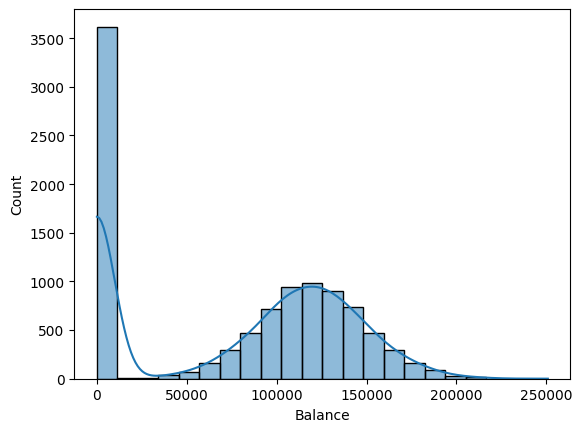

In [68]:
sns.histplot(df['Balance'],kde=True)

<Axes: xlabel='Tenure', ylabel='Count'>

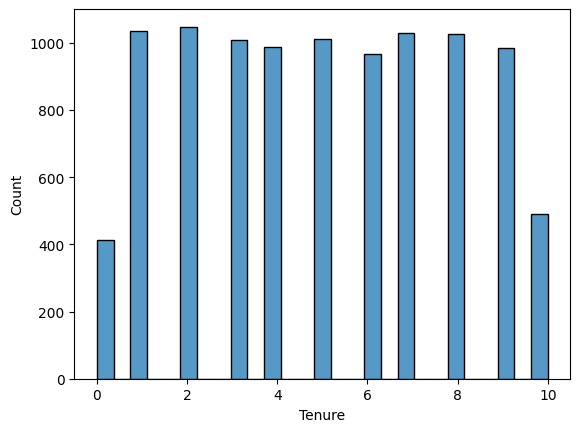

In [69]:
sns.histplot(df['Tenure'])


In [70]:
x=df.drop('Exited',axis=1)
y=df['Exited']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=34)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [72]:
preprocessor = ColumnTransformer(transformers=[
    ('geo', OneHotEncoder(drop='first'), [1]),
    ('gender', OneHotEncoder(drop='first'), [2]),
    ('num', StandardScaler(), [0,3,4,5,6,7,8,9])
])

model = XGBClassifier(
    n_estimators=550,
    max_depth=5,
    learning_rate=0.08,
    random_state=45
)

pipe=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('sampling',SMOTE(random_state=34)), # type: ignore
    ('model',model)
])

In [73]:
pipe.fit(x_train,y_train)
y_pred=pipe.predict(x_test)


In [74]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.8575
0.7264437689969605
0.5506912442396313
0.6264744429882044


In [75]:
import joblib

joblib.dump(pipe,'Model.pkl')


['Model.pkl']